In [1]:
import pandas as pandas

# Carregamento do conjunto de dados brutos
caminho_dados = "../dados/dados_brutos.csv"
tabela_imoveis = pandas.read_csv(caminho_dados)

# Exibição do conjunto de dados
tabela_imoveis

,tamanho_metros_quadrados,quantidade_quartos,distancia_centro_quilometros,preco_reais
0,50,1,12,250000
1,70,2,10,320000
2,85,2,8,380000
3,110,3,5,510000
4,150,3,4,680000
5,200,4,3,890000
6,240,4,2,1050000
7,300,5,1,1350000


In [2]:
# Exibindo informações gerais da base de dados (quantidade de linhas, colunas e tipos de dados)
tabela_imoveis.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   tamanho_metros_quadrados      8 non-null      int64
 1   quantidade_quartos            8 non-null      int64
 2   distancia_centro_quilometros  8 non-null      int64
 3   preco_reais                   8 non-null      int64
dtypes: int64(4)
memory usage: 388.0 bytes


In [4]:
# Gerando a tabela de estatística descritiva
tabela_imoveis.describe()

,tamanho_metros_quadrados,quantidade_quartos,distancia_centro_quilometros,preco_reais
count,8.000000,8.000000,8.000000,8.000000e+00
mean,150.625000,3.000000,5.625000,6.787500e+05
std,88.899522,1.309307,3.961872,3.897412e+05
min,50.000000,1.000000,1.000000,2.500000e+05
25%,81.250000,2.000000,2.750000,3.650000e+05
50%,130.000000,3.000000,4.500000,5.950000e+05
75%,210.000000,4.000000,8.500000,9.300000e+05
max,300.000000,5.000000,12.000000,1.350000e+06


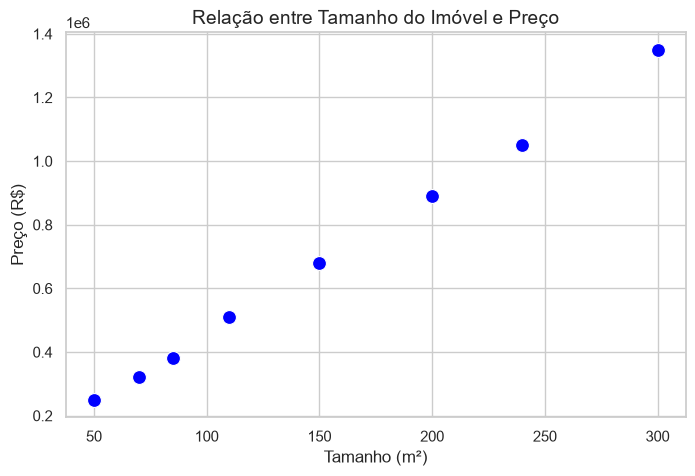

In [7]:
import matplotlib.pyplot as matplotlib
import seaborn as seaborn

# Configurando o estilo visual dos gráficos
seaborn.set_theme(style="whitegrid")

# Criando a figura do gráfico
matplotlib.figure(figsize=(8, 5))

# Gerando o gráfico de dispersão: Tamanho do Imóvel vs Preço
seaborn.scatterplot(
    data=tabela_imoveis,
    x='tamanho_metros_quadrados',
    y='preco_reais',
    color='blue',
    s=100
)

# Definindo títulos e rótulos dos eixos
matplotlib.title("Relação entre Tamanho do Imóvel e Preço", fontsize=14)
matplotlib.xlabel("Tamanho (m²)", fontsize=12)
matplotlib.ylabel("Preço (R$)", fontsize=12)

# Exibindo o gráfico na tela
matplotlib.show()

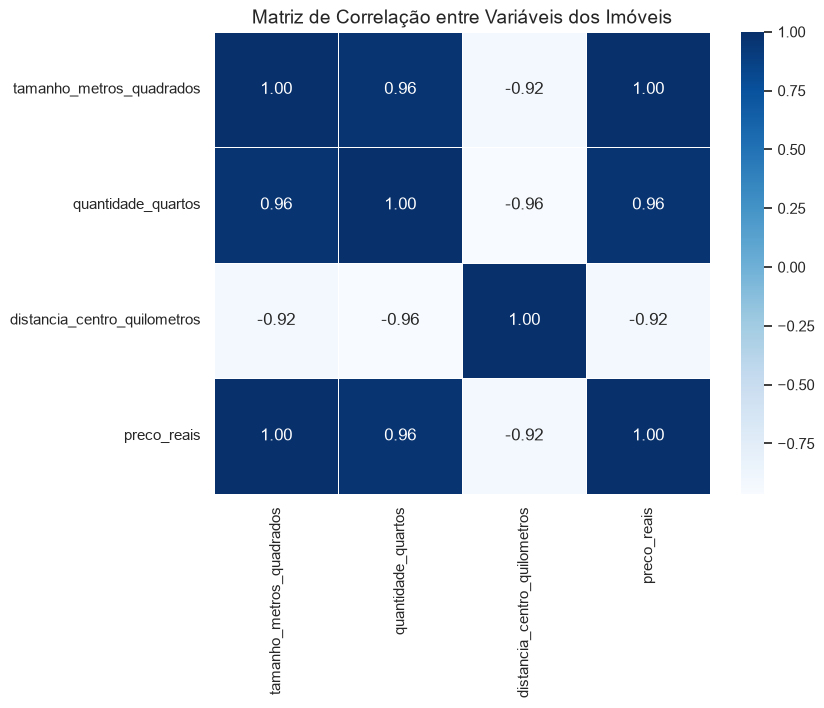

In [14]:
# Calculando a matriz de correlação numérica
matriz_correlacao = tabela_imoveis.corr()

# Configurando o tamanho da figura do mapa de calor
matplotlib.figure(figsize=(8, 6))

# Gerando o mapa de calor com os valores de correlação
seaborn.heatmap(
    matriz_correlacao, 
    annot=True, 
    cmap='Blues', 
    fmt='.2f', 
    linewidths=0.5
)

# Definindo o título do gráfico
matplotlib.title("Matriz de Correlação entre Variáveis dos Imóveis", fontsize=14)

# Exibindo o gráfico
matplotlib.show()



In [9]:
from sklearn.model_selection import train_test_split

# 1. Separando as variáveis explicativas (X) da variável que queremos prever (y)
X = tabela_imoveis[['tamanho_metros_quadrados', 'quantidade_quartos', 'distancia_centro_quilometros']]
y = tabela_imoveis['preco_reais']

# 2. Dividindo os dados: 75% para treino do modelo e 25% para teste futuro
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42)

# Exibindo quantas casas ficaram para treino e quantas para teste
print(f"Quantidade de imóveis para treino: {len(X_treino)}")
print(f"Quantidade de imóveis para teste: {len(X_teste)}")

Quantidade de imóveis para treino: 6
Quantidade de imóveis para teste: 2


In [10]:
from sklearn.linear_model import LinearRegression

# 1. Criando a estrutura vazia do modelo de Regressão Linear
modelo_previsao = LinearRegression()

# 2. Treinando o modelo (o algoritmo vai aprender os padrões com os dados de treino)
modelo_previsao.fit(X_treino, y_treino)

print("Treinamento concluído com sucesso!")

Treinamento concluído com sucesso!


In [11]:
import joblib

# Caminho onde o arquivo do modelo será gravado
caminho_modelo = "../modelos/modelo_previsao_imoveis.joblib"

# Salvando o modelo treinado no disco
joblib.dump(modelo_previsao, caminho_modelo)

print("Modelo treinado e salvo com sucesso na pasta 'modelos'!")

Modelo treinado e salvo com sucesso na pasta 'modelos'!


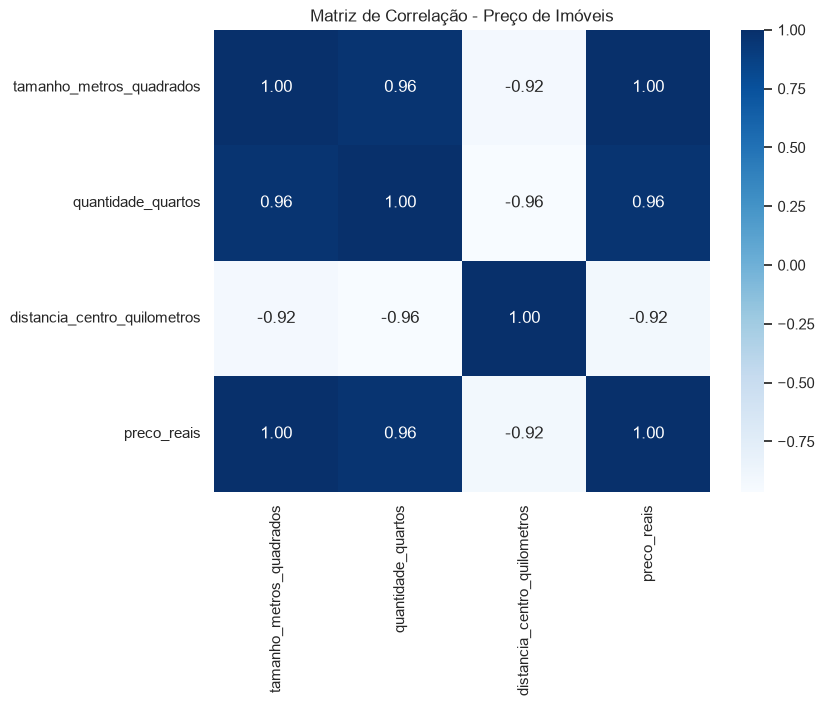

In [15]:
import matplotlib.pyplot as matplotlib
import seaborn as seaborn

matplotlib.figure(figsize=(8, 6))

# 1. Desenha o mapa de calor
seaborn.heatmap(tabela_imoveis.corr(), annot=True, cmap='Blues', fmt='.2f')
matplotlib.title("Matriz de Correlação - Preço de Imóveis")

# 2. SALVA PRIMEIRO (antes de exibir na tela)
matplotlib.savefig("../relatorios/grafico_correlacao.png", dpi=300, bbox_inches='tight')

# 3. EXIBE NA TELA DEPOIS
matplotlib.show()

In [17]:
import pandas as pandas
import joblib

# 1. Carregando o modelo salvo
modelo_carregado = joblib.load("../modelos/modelo_previsao_imoveis.joblib")

# 2. Passando o imóvel novo como um DataFrame com os mesmos nomes das colunas do treino
novo_imovel = pandas.DataFrame([{
    'tamanho_metros_quadrados': 120,
    'quantidade_quartos': 3,
    'distancia_centro_quilometros': 4
}])

# 3. Fazendo a previsão
preco_previsto = modelo_carregado.predict(novo_imovel)

print(f"Preço estimado para o novo imóvel: R$ {preco_previsto[0]:,.2f}")

Preço estimado para o novo imóvel: R$ 541,270.70
